In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point
from shapely.geometry import LineString, Point
import numpy as np

# Configuration

In [3]:
tolerance  = 2
street_length = 20

# Generate the arbitrary pass

## Arbitrary survey

In [4]:
import pandas as pd
import geopandas as gpd

# Create a DataFrame with the pass name and geometries
survey_gdf = gpd.GeoDataFrame({
    'Order': [1,2,3,4,5],
    'geometry': [
        LineString([(-800, -800),(0, 0),(-800, 800)]),
        LineString([(800, 800),(0, 700),(-800, 800)]),
        LineString([(800, 800),(0,0 ),(800, -800)]),
        LineString([(775, 775),(0, 675)]),
        LineString([(810, 810),(0, 735)])
    ]
}, geometry='geometry', crs='EPSG:3857')

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()
/tmp/ipykernel_8957/327293463.py:2: DeprecationWarning: GeoPandas is set to use PyGEOS over Shapely. PyGEOS support is deprecatedand will be removed in GeoPandas 1.0, released in the Q1 of 2024. Please migrate to Shapely 2.0 (https://geopandas.org/en/stable/docs/user_guide/pygeos_to_shapely.html).
  import geopandas as gpd


In [5]:
# Compute the union of the survey geometries
survey_union = survey_gdf.unary_union

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [6]:
survey_union_offset_gdf['boundary'] = survey_union_offset_gdf.geometry.boundary
boundary_gdf = survey_union_offset_gdf[['boundary']]
boundary_gdf.set_geometry('boundary', inplace=True)
boundary_gdf.set_crs('EPSG:3857', inplace=True)


/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,boundary
0,"MULTILINESTRING ((-807.071 792.929, -800.000 8..."


In [7]:
from shapely.geometry import MultiLineString, LineString

# Segment the boundary into individual LineStrings if it's a MultiLineString
segmented_lines = []
for geom in boundary_gdf['boundary']:
    if isinstance(geom, MultiLineString):
        segmented_lines.extend(list(geom.geoms))
    elif isinstance(geom, LineString):
        segmented_lines.append(geom)

segmented_gdf = gpd.GeoDataFrame({'geometry': segmented_lines}, crs=boundary_gdf.crs)
segmented_gdf

,geometry
0,"LINESTRING (-807.071 792.929, -800.000 800.000..."
1,"LINESTRING (-0.000 14.142, 747.186 761.328, 1...."


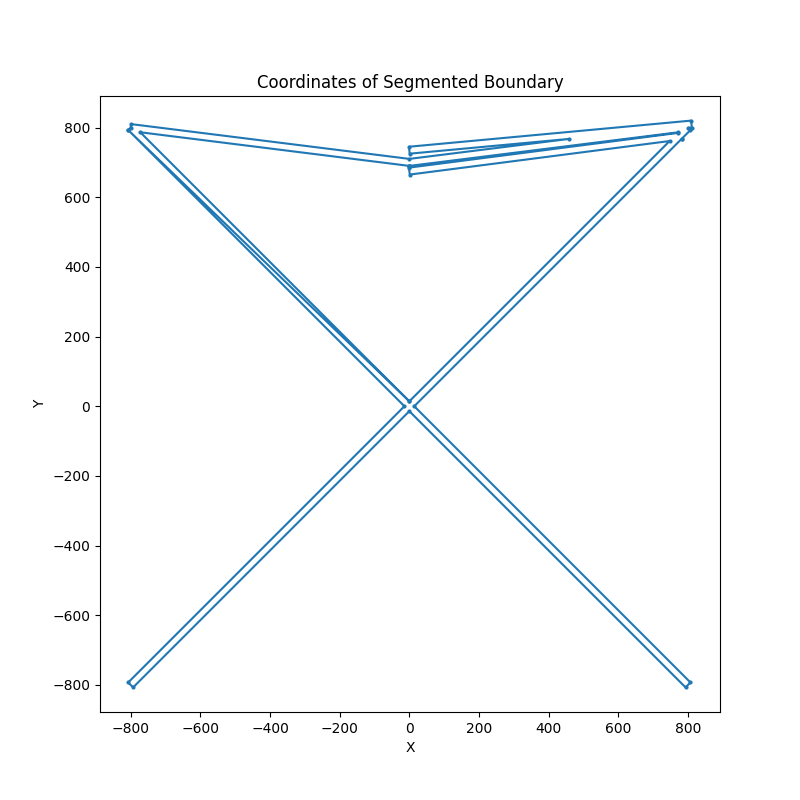

In [8]:
import matplotlib.pyplot as plt

# Extract coordinates from all LineStrings
all_coords = []
for geom in segmented_gdf['geometry']:
    coords = list(geom.coords)
    all_coords.extend(coords)

x, y = zip(*all_coords)

plt.figure(figsize=(8, 8))
plt.plot(x, y, 'o-', markersize=2)
plt.title("Coordinates of Segmented Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.show()

# Generate the grid

In [9]:
min_x = -1000
max_x = 1000
min_y = -1000
max_y = 1000
dx = 0.5
# Create the set of grid lines
x_coords = np.arange(min_x, max_x, 20)
vertical_lines = [LineString([(x, min_y), (x, max_y)]) for x in x_coords]
geometry_z = [Point(x, max_y) for x in x_coords]
grid_lines_gdf = gpd.GeoDataFrame(vertical_lines, columns=['geometry'], crs='EPSG:3857', geometry='geometry')
grid_lines_gdf = grid_lines_gdf.reset_index().rename(columns={'index': 'line_index'})
grid_lines_gdf['dx'] = grid_lines_gdf.apply(lambda row: row.geometry.parallel_offset(dx, side='right'), axis=1)

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [10]:
intersection_gdf = gpd.overlay(
    grid_lines_gdf, 
    survey_union_offset_gdf.set_geometry(survey_union_offset_gdf.geometry.boundary), 
    how='intersection', 
    keep_geom_type=False
)
intersection_gdf = intersection_gdf.explode(index_parts=True)
intersection_gdf.set_geometry('geometry', inplace=True)
intersection_gdf.set_crs('EPSG:3857', inplace=True)
#intersection_gdf.rename(columns={'geometry': 'geometry_x'}, inplace=True)
# The overlay operation needs both GeoDataFrames to have an active geometry column. 
# grid_lines_gdf[['dx']] does not have its geometry column set, so let's set it.
grid_lines_dx = grid_lines_gdf.copy()
grid_lines_dx = grid_lines_dx.set_geometry('dx')
grid_lines_dx.crs = grid_lines_gdf.crs
# Now perform the overlay
intersection_gdf_dx = gpd.overlay(
    grid_lines_dx, 
    survey_union_offset_gdf.set_geometry(survey_union_offset_gdf.geometry.boundary), 
    how='intersection', 
    keep_geom_type=False
)
intersection_gdf_dx = intersection_gdf_dx.explode(column='geometry', index_parts=True)
intersection_gdf_dx.set_geometry('geometry', inplace=True)
intersection_gdf_dx.crs = 'EPSG:3857'
#intersection_gdf_dx.rename(columns={'geometry': 'geometry_y'}, inplace=True)

In [11]:
intersection_gdf_dx.index.rename(['main_index', 'sub_index'], inplace=True)
intersection_gdf.index.rename(['main_index', 'sub_index'], inplace=True)

In [12]:
# For each geometry in intersection_gdf_dx, find the closest geometry to it and relate them together

from shapely.ops import nearest_points

# Invert: For each geometry in intersection_gdf, find the closest geometry in intersection_gdf_dx

# Extract all geometries and indices for both GeoDataFrames
base_geometries = list(intersection_gdf.geometry)
base_indices = list(intersection_gdf.index)
dx_geometries = list(intersection_gdf_dx.geometry)
dx_indices = list(intersection_gdf_dx.index)

# For each geometry in intersection_gdf, find the closest geometry in intersection_gdf_dx
closest_indices = []
closest_geometries = []
closest_distances = []

for i, geom in enumerate(base_geometries):
    min_dist = np.inf
    closest_geom = None
    closest_index = None
    for j, other_geom in enumerate(dx_geometries):
        dist = geom.distance(other_geom)
        if dist < min_dist:
            min_dist = dist
            closest_geom = other_geom
            closest_index = dx_indices[j]
    closest_geometries.append(closest_geom)
    closest_indices.append(closest_index)
    closest_distances.append(min_dist)

# Add closest relation columns to the intersection_gdf dataframe
intersection_gdf['closest_geometry'] = closest_geometries
intersection_gdf['closest_index'] = closest_indices
intersection_gdf['closest_distance'] = closest_distances

intersection_gdf.rename(columns={'geometry': 'geometry_x', 'closest_geometry': 'geometry_y'}, inplace=True)
intersection_gdf

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


line_index  \
main_index sub_index               
0          0                  10   
           1                  10   
           2                  10   
           3                  10   
1          0                  11   
...                          ...   
79         3                  89   
80         0                  90   
           1                  90   
           2                  90   
           3                  90   

                                                                     dx  \
main_index sub_index                                                      
0          0          LINESTRING (-799.500 1000.000, -799.500 -1000....   
           1          LINESTRING (-799.500 1000.000, -799.500 -1000....   
           2          LINESTRING (-799.500 1000.000, -799.500 -1000....   
           3          LINESTRING (-799.500 1000.000, -799.500 -1000....   
1          0          LINESTRING (-779.500 1000.000, -779.500 -1000....   
...                                                                 ...   
79         3           LINESTRING (780.500 1000.000, 780.500 -1000.000)   
80         0           LINESTRING (800.500 1000.000, 800.500 -1000.000)   
           1           LINESTRING (800.500 1000.000, 800.500 -1000.000)   
           2           LINESTRING (800.500 1000.000, 800.500 -1000.000)   
           3           LINESTRING (800.500 1000.000, 800.500 -1000.000)   

                                                               boundary  \
main_index sub_index                                                      
0          0          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           1          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           2          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           3          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
1          0          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
...                                                                 ...   
79         3          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
80         0          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           1          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           2          MULTILINESTRING ((-807.071 792.929, -800.000 8...   
           3          MULTILINESTRING ((-807.071 792.929, -800.000 8...   

                                     geometry_x  \
main_index sub_index                              
0          0          POINT (-800.000 -800.000)   
           1          POINT (-800.000 -785.858)   
           2           POINT (-800.000 785.858)   
           3           POINT (-800.000 800.000)   
1          0          POINT (-780.000 -794.142)   
...                                         ...   
79         3            POINT (780.000 765.858)   
80         0            POINT (800.000 785.858)   
           1            POINT (800.000 819.117)   
           2           POINT (800.000 -800.000)   
           3           POINT (800.000 -785.858)   

                                             geometry_y closest_index  \
main_index sub_index                                                    
0          0                      POINT (-799.5 -800.5)        (0, 3)   
           1          POINT (-799.5 -785.3578643762692)        (0, 2)   
           2           POINT (-799.5 785.3578643762692)        (0, 1)   
           3           POINT (-799.5 803.9999999999999)        (0, 0)   
1          0          POINT (-779.5 -793.6421356237308)        (1, 2)   
...                                                 ...           ...   
79         3            POINT (780.5 766.3578643762689)       (79, 1)   
80         0            POINT (800.5 786.3578643762692)       (80, 1)   
           1             POINT (800.5 819.163145824412)       (80, 0)   
           2                       POINT (800.5 -799.5)       (80, 2)   
           3           POINT (800.5 -786.3578643762692)      

In [13]:
# Remove all points from intersection_gdf where the closest_distance is greater than dx

intersection_gdf = intersection_gdf[intersection_gdf['closest_distance'] <= 1].copy()
intersection_gdf.reset_index(inplace=True)


In [14]:
# Take the unit vector from p1 (Point) to p2 (Point)
def unit_vector_between_points(p1, p2):
    try:
        if p1 is None or p2 is None:
            return np.array([np.nan, np.nan])
        x0, y0 = p1.x, p1.y
        x1, y1 = p2.x, p2.y
        dx = x1 - x0
        dy = y1 - y0
        norm = np.sqrt(dx**2 + dy**2)
        if norm == 0:
            return np.array([np.nan, np.nan])
        return np.array([dx/norm, dy/norm])
    except Exception:
        return np.array([np.nan, np.nan])

# Assuming you want to calculate unit vectors between two columns of points in intersection_gdf,
# replace 'geometry_x' and 'geometry_y' below with the actual relevant column names as needed.  

intersection_gdf['u2'] = intersection_gdf.apply(lambda row: unit_vector_between_points(row['geometry_x'], row['geometry_y']), axis=1)

In [15]:
intersection_gdf['inv'] = intersection_gdf['u2'].apply(lambda arr: arr[::-1] if isinstance(arr, (list, np.ndarray)) else arr)
intersection_gdf['inv'] = intersection_gdf['inv'].apply(
    lambda arr: [-arr[0], arr[1]] if isinstance(arr, (list, np.ndarray)) and len(arr) == 2 and not np.isnan(arr[0]) and not np.isnan(arr[1]) else arr
)

In [16]:
from shapely.geometry import Point, LineString

def point_from_vec(base_point, vec):
    # base_point: shapely Point
    # vec: [dx, dy]
    if not isinstance(base_point, Point):
        return None
    if not isinstance(vec, (list, np.ndarray)) or len(vec) != 2:
        return None
    if np.isnan(vec[0]) or np.isnan(vec[1]):
        return None
    return Point(base_point.x + vec[0], base_point.y + vec[1])

# Create the new point by adding inv vector to geometry_x, then create line to geometry_x
intersection_gdf['inv_point'] = intersection_gdf.apply(
    lambda row: point_from_vec(row['geometry_x'], row['inv']), axis=1
)
intersection_gdf['inv_line'] = intersection_gdf.apply(
    lambda row: LineString([row['geometry_x'], row['inv_point']]) 
        if isinstance(row['geometry_x'], Point) and isinstance(row['inv_point'], Point)
        else None,
    axis=1
)
from shapely.geometry import LineString

def extrapolate_line_shapely(line, distance=10):
    """
    Extrapolate the line by 'distance' units beyond its end based on direction.
    Only works for LineStrings with exactly 2 points.
    """
    if not isinstance(line, LineString) or len(line.coords) != 2:
        return None
    x0, y0 = line.coords[0]
    x1, y1 = line.coords[1]
    dx = x1 - x0
    dy = y1 - y0
    length = np.hypot(dx, dy)
    if length == 0:
        return None
    # Normalize direction
    dx_norm = dx / length
    dy_norm = dy / length
    # Extrapolate beyond (x1, y1)
    x2 = x1 + dx_norm * distance
    y2 = y1 + dy_norm * distance
    # Create new LineString: start, end, extrapolated point
    return LineString([(x0, y0), (x1, y1), (x2, y2)])

intersection_gdf['inv_line_extrapolated'] = intersection_gdf['inv_line'].apply(
    lambda line: extrapolate_line_shapely(line, distance=street_length*10)
)

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [17]:
# Filter: keep only those rows whose geometry_y is within survey_gdf_offset
inside_gdf = intersection_gdf[intersection_gdf['inv_point'].apply(lambda geom: survey_union_offset_gdf.contains(geom).any() if geom is not None else False)].copy()

<Axes: >

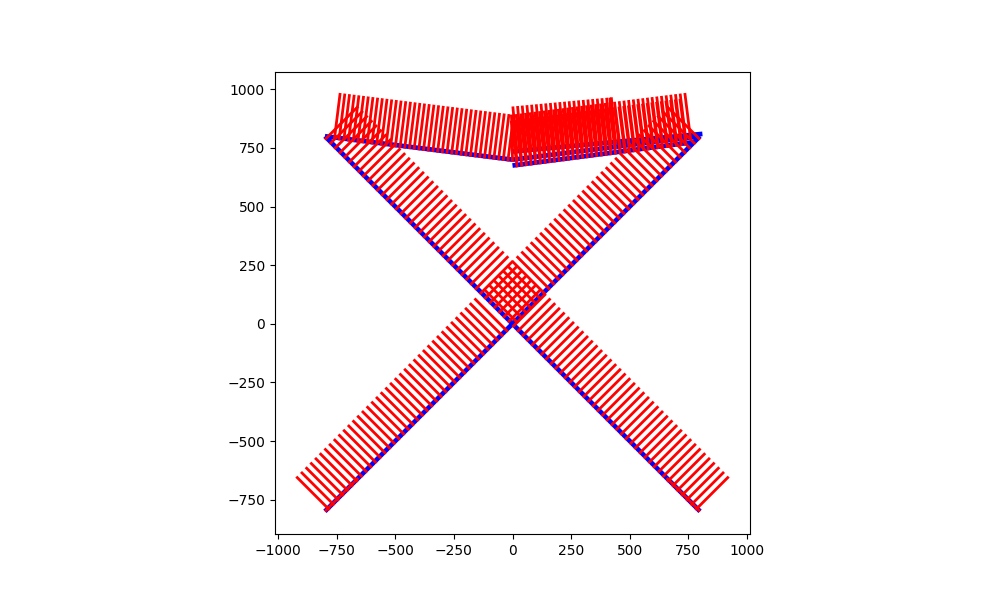

In [18]:
fig,ax2 = plt.subplots(figsize=(10,6))
inside_gdf.set_geometry('inv_line_extrapolated').plot(ax=ax2, color='red', linewidth=2, label='inv_line_extrapolated')
survey_union_offset_gdf.plot(ax=ax2, color='blue', linewidth=2, label='survey_union_offset_gdf')